In [1]:
!pip install pandas 
!pip install --upgrade pandas
!pip install seaborn
!pip install matplotlib
!pip install scipy


[notice] A new release of pip is available: 24.2 -> 24.3.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 24.2 -> 24.3.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 24.2 -> 24.3.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 24.2 -> 24.3.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 24.2 -> 24.3.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import seaborn as sns
from matplotlib import pyplot as plt
import pandas as pd
import numpy as np

In [ ]:
# load datasets
cyclists = pd.read_csv('dataset/dataset/cyclists.csv')
races = pd.read_csv('dataset/dataset/races.csv')


# Races dataset

In [4]:
races.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 589865 entries, 0 to 589864
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   _url                 589865 non-null  object 
 1   name                 589865 non-null  object 
 2   points               589388 non-null  float64
 3   uci_points           251086 non-null  float64
 4   length               589865 non-null  float64
 5   climb_total          442820 non-null  float64
 6   profile              441671 non-null  float64
 7   startlist_quality    589865 non-null  int64  
 8   average_temperature  29933 non-null   float64
 9   date                 589865 non-null  object 
 10  position             589865 non-null  int64  
 11  cyclist              589865 non-null  object 
 12  cyclist_age          589752 non-null  float64
 13  is_tarmac            589865 non-null  bool   
 14  is_cobbled           589865 non-null  bool   
 15  is_gravel        

Here we can see unique values:
- there are 61 different races
- points is more like a categorical value (only 14 different values)
- 5 different profiles
- is_cobbled and is_gravel must be studied because they have only a single unique value

In [5]:
races.nunique()

_url                     5281
name                       61
points                     14
uci_points                 20
length                   1280
climb_total              2117
profile                     5
startlist_quality         697
average_temperature        27
date                   140509
position                  210
cyclist                  6095
cyclist_age                29
is_tarmac                   2
is_cobbled                  1
is_gravel                   1
cyclist_team               91
delta                    2836
dtype: int64

A lot of null values for uci_points and average_temperature, slightly less null values for climb_total, profile and cyclist_team.\
Null values for points and cyclist_age are negligible.

In [6]:
races.isnull().sum()

_url                        0
name                        0
points                    477
uci_points             338779
length                      0
climb_total            147045
profile                148194
startlist_quality           0
average_temperature    559932
date                        0
position                    0
cyclist                     0
cyclist_age               113
is_tarmac                   0
is_cobbled                  0
is_gravel                   0
cyclist_team           159161
delta                       0
dtype: int64

Heatmap to visualize null values, average temperature is null almost for each entry.

<Axes: >

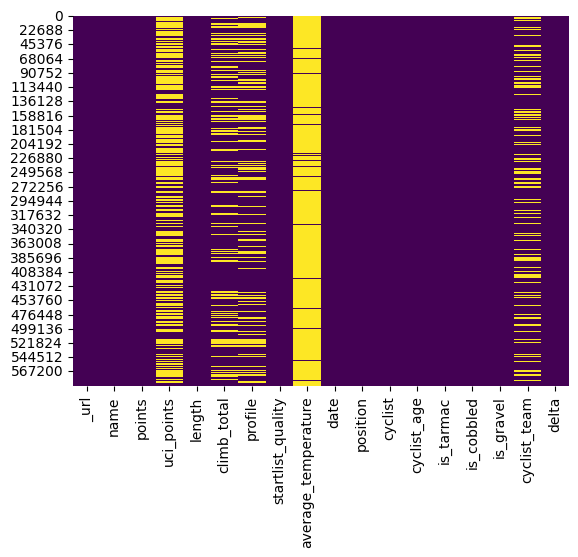

In [7]:
sns.heatmap(races.isnull(), cbar=False, cmap='viridis')  # .isnull() restituisce True per valori NaN


In [8]:
# Let's see again is_tarmac, is_cobbled, is_gravel

print(races['is_tarmac'].value_counts())
print(races['is_cobbled'].value_counts())
print(races['is_gravel'].value_counts())

is_tarmac
True     536042
False     53823
Name: count, dtype: int64
is_cobbled
False    589865
Name: count, dtype: int64
is_gravel
False    589865
Name: count, dtype: int64


1) Delete is_cobbled and is_gravel
2) Check consistency of is_tarmac (no false and true for the same race)
3) if is_tarmac is consistent keep it

In [ ]:
# Control of the consistency of false data of 'is_tarmac'
# Per vedere se per la solita gara abbiamo diversi valori di 'is_tarmac'
consistency = races.groupby('_url')['is_tarmac'].nunique()

# Find races with inconstistency
inconsistent_races = consistency[consistency > 1].index

# Show inconsistent races
if len(inconsistent_races) > 0:
    print("Inconsistent races:", inconsistent_races.tolist())
else:
    print("No inconsistent races")

No inconsistent races


Check consistency of points

In [ ]:
# Control of the consistency of  'points'
# Check if the value of points is the same for each entry of the same race

consistency = races.groupby('_url')['points'].nunique()

# Find races with inconstistency
inconsistent_races = consistency[consistency > 1].index

# Show inconsistent races
if len(inconsistent_races) > 0:
    print("Inconsistent races:", inconsistent_races.tolist())
else:
    print("No inconsistent races")

No inconsistent races


Check consistency of uci_points

In [ ]:
# Control of the consistency of  'points'
# Check if the value of points is the same for each entry of the same race

consistency = races.groupby('_url')['uci_points'].nunique()

# Find races with inconstistency
inconsistent_races = consistency[consistency > 1].index

# Show inconsistent races
if len(inconsistent_races) > 0:
    print("Inconsistent races:", inconsistent_races.tolist())
else:
    print("No inconsistent races")

No inconsistent races


Check if points and uci_points can be merged or if we can impute one value using the other

In [12]:
righe_null = races[races['points'].isnull() & races['uci_points'].isnull()]

print("Rows where both columns are null:")
print(f'{len(righe_null)} rows where are both null')

Rows where both columns are null:
477 rows where are both null


Since they cannot be merged (points has only 477 null values and uci_points is always null in those rows), what about checking the overall correlation and delete one?

In [13]:
races_numerical = races.select_dtypes(include=[float, int])

races_numerical.isnull().sum()

points                    477
uci_points             338779
length                      0
climb_total            147045
profile                148194
startlist_quality           0
average_temperature    559932
position                    0
cyclist_age               113
delta                       0
dtype: int64

<Axes: >

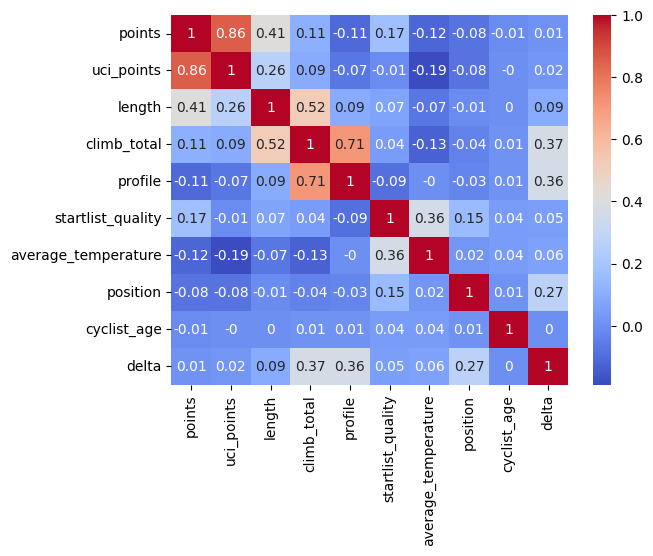

In [14]:
# Correlation matrix
correlation = races_numerical.corr('pearson')
sns.heatmap(correlation.round(2),annot=True, cmap='coolwarm')

Scatterplot to see trend for points with respect to uci_points

<Axes: xlabel='points', ylabel='uci_points'>

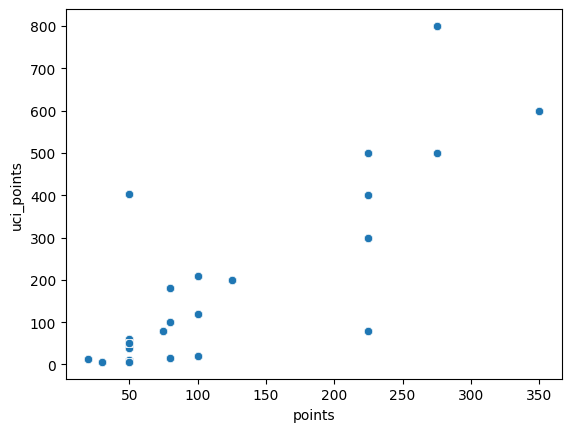

In [15]:
sns.scatterplot(races, x=races['points'], y=races['uci_points'])

# Drop uci_points

Since uci_points is mostly null and is highly correlated with points we decided to remove uci_points keeping only points as indicator.\
Also uci_points has some strange values, maybe anomalies, sometimes it has different (unrealistic) values in correspondence with points:\
<span style="color: green;">url:</span>\
volta-a-catalunya/2015/stage-4\
<span style="color: green;">name:</span>\
Volta Ciclista a Catalunya\
<span style="color: green;">points:</span>\
50\
<span style="color: green;">uci_points:</span>\
6\
maybe there is a mistake and it was meant to be 60 instad of 6? Since we don't know, it is better to avoid using it

# Drop average_temperature
Since average_temperature is mostly null (95% null values), delete it.

# Drop cyclist_team
Cyclist team is a feature that has a reasonable amount of null values, a first solution could be treating missing values as a cyclist with no team, but
after a brief search online it seems like a cyclist cannot race without a team in most important races such as Tour de France, so in this first phase we decided to drop the column.

# Drop features

In [16]:
races_final = races.drop(columns=['uci_points','average_temperature','is_cobbled','is_gravel','cyclist_team'])
races_final.isnull().sum()

_url                      0
name                      0
points                  477
length                    0
climb_total          147045
profile              148194
startlist_quality         0
date                      0
position                  0
cyclist                   0
cyclist_age             113
is_tarmac                 0
delta                     0
dtype: int64

# Study climb_total and profile

In [17]:
# Check if climb_total and profile values can be imputed using the other (With knn or others)

righe_null = len(races[races['climb_total'].isnull() & races['profile'].isnull()])

print("Rows where both columns are null:")
print(f'{righe_null} out of {races["climb_total"].isnull().sum()} null values for climb_total and {races["profile"].isnull().sum()} null values for profile')

rows = races.shape[0]

print(races['climb_total'].isnull().sum()/rows*100)
print(races['profile'].isnull().sum()/rows*100)

print(f'percentage of rows where only one feature is null:\n{righe_null/rows*100}')



Rows where both columns are null:
114466 out of 147045 null values for climb_total and 148194 null values for profile
24.928585354275977
25.123375687657344
percentage of rows where only one feature is null:
19.40545718088037


# Impute profile from climb_total and length and delete climb_total

Profile is a useful class, because it can be useful for dividing cyclists and races into categories,\
So it could be good to impute profile using climb_total and length since they are correlated according to spearman and pearson correlation.\
Leaving this column results in a loss of ~19.4% of data (because of the null records drop), but since it could be very useful to the analysis, we decided to keep it.

In [18]:
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# Copy of races
races_imputed = races_final.copy()

# Create a "training set" to train the classifier, so drop rows where one value or both are null (length is never null), also try a test to see how good it is on the estimation
complete_data_classification = races_imputed.dropna(subset=['climb_total', 'profile'])
X = complete_data_classification.drop(columns=['profile'])  # Replace 'target_column' with your actual target
y = complete_data_classification['profile']

# Create the train+test set
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=11,
    stratify=y
)

# KNNClassifier based on climb_total and length
knn_classifier_test = KNeighborsClassifier(n_neighbors=10)
knn_classifier_test.fit(X_train[['climb_total', 'length']], y_train)

# Prediction
predictions = knn_classifier_test.predict(X_test[['climb_total', 'length']])


# Generate a classification report to see performances
report = classification_report(y_test, predictions)
print("Classification Report:")
print(report)


Classification Report:
              precision    recall  f1-score   support

         1.0       1.00      1.00      1.00     24576
         2.0       1.00      1.00      1.00     22752
         3.0       0.99      1.00      0.99      9124
         4.0       0.99      0.99      0.99      8330
         5.0       1.00      1.00      1.00     17037

    accuracy                           1.00     81819
   macro avg       1.00      1.00      1.00     81819
weighted avg       1.00      1.00      1.00     81819



- Results are very good, so we can safely impute values.
- Retrain the model with the whole set (train+test) in order to be more precise.

In [19]:
# retrain the model on the whole set (train+test)
# KNNClassifier based on climb_total and length
knn_classifier = KNeighborsClassifier(n_neighbors=10)
knn_classifier.fit(complete_data_classification[['climb_total', 'length']], complete_data_classification[['profile']])

# Impute 'profile' where is null but 'climb_total' has a valid value
missing_profile = races_imputed['profile'].isnull() & races_imputed['climb_total'].notnull()
races_imputed.loc[missing_profile, 'profile'] = knn_classifier.predict(races_imputed.loc[missing_profile, ['climb_total','length']])


c:\Users\Fede\Desktop\Data-Mining-24-25\.venv\Lib\site-packages\sklearn\neighbors\_classification.py:238: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


- Let's see if the distribution before and after the imputation is preserved.

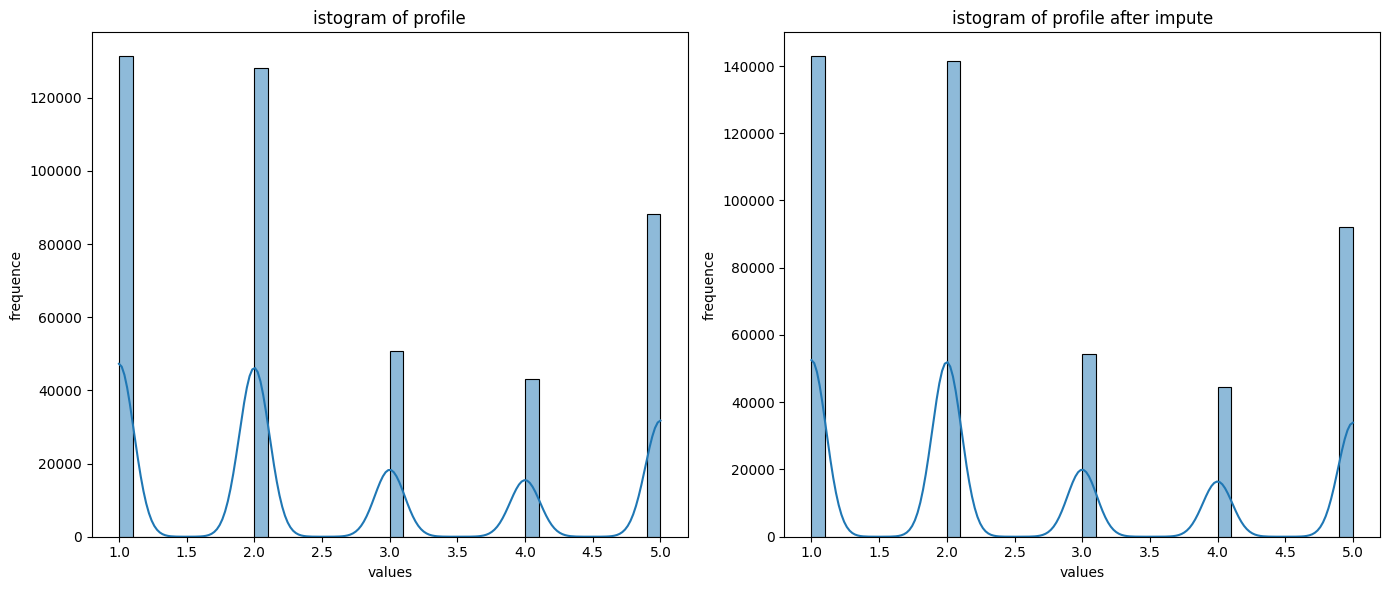

In [ ]:
columns_to_select = ['profile']

for col in columns_to_select:
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # Istogramma
    sns.histplot(races[col].dropna(), bins=40, kde=True, ax=axes[0], edgecolor='black')
    axes[0].set_title(f'istogram of {col}')
    axes[0].set_xlabel('values')
    axes[0].set_ylabel('frequence')
    
    # Istogramma
    sns.histplot(races_imputed[col].dropna(), bins=40, kde=True, ax=axes[1], edgecolor='black')
    axes[1].set_title(f'istogram of {col} after impute')
    axes[1].set_xlabel('values')
    axes[1].set_ylabel('frequence')
    
    plt.tight_layout()
    plt.show()



- Control of the consistency of 'profile' after the imputation
- Check if the value of profile is the same for each entry of the same race

In [ ]:
consistency = races.groupby('_url')['profile'].nunique()

# Find races with inconstistency
inconsistent_races = consistency[consistency > 1].index

# Show inconsistent races
if len(inconsistent_races) > 0:
    print("Inconsistent races:", inconsistent_races.tolist())
else:
    print("No inconsistent races")

No inconsistent races


In [22]:
races_imputed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 589865 entries, 0 to 589864
Data columns (total 13 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   _url               589865 non-null  object 
 1   name               589865 non-null  object 
 2   points             589388 non-null  float64
 3   length             589865 non-null  float64
 4   climb_total        442820 non-null  float64
 5   profile            475399 non-null  float64
 6   startlist_quality  589865 non-null  int64  
 7   date               589865 non-null  object 
 8   position           589865 non-null  int64  
 9   cyclist            589865 non-null  object 
 10  cyclist_age        589752 non-null  float64
 11  is_tarmac          589865 non-null  bool   
 12  delta              589865 non-null  float64
dtypes: bool(1), float64(6), int64(2), object(4)
memory usage: 54.6+ MB


- Drop climb_total

In [23]:
races_imputed = races_imputed.drop(columns=['climb_total'])

In [24]:
races_imputed = races_imputed.dropna(subset=['profile'])
races_imputed.isnull().sum()

_url                   0
name                   0
points               477
length                 0
profile                0
startlist_quality      0
date                   0
position               0
cyclist                0
cyclist_age          105
is_tarmac              0
delta                  0
dtype: int64

# Feature removed until now

_url\
name\
points\
<span style="color: red;">uci_points </span> deleted because many values are missing and we use points\
length\
<span style="color: red;">climb_total </span> deleted because many values are missing and we use profile because highly correlated\
profile\
startlist_quality\
<span style="color: red;">average_temperature </span> deleted because many values are missing \
date\
position\
cyclist\
cyclist_age\
is_tarmac\
<span style="color: red;">is_cobbled </span> deleted because all false \
<span style="color: red;">is_gravel </span> deleted because all false \
<span style="color: red;">cyclist_team </span> deleted because many values are missing \
delta



# Cylcists dataset

In [25]:
cyclists.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6134 entries, 0 to 6133
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   _url         6134 non-null   object 
 1   name         6134 non-null   object 
 2   birth_year   6121 non-null   float64
 3   weight       3078 non-null   float64
 4   height       3143 non-null   float64
 5   nationality  6133 non-null   object 
dtypes: float64(3), object(3)
memory usage: 287.7+ KB


<Axes: >

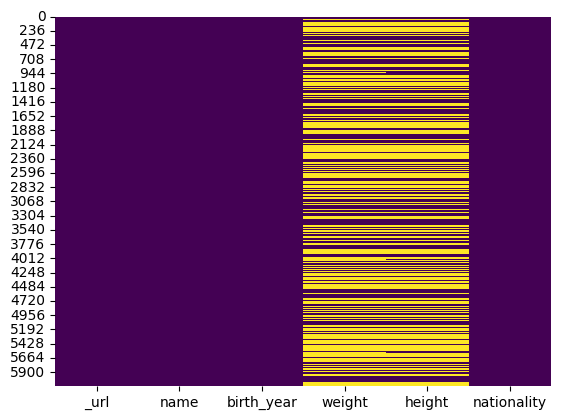

In [26]:
sns.heatmap(cyclists.isnull(), cbar=False, cmap='viridis')  # .isnull() restituisce True per valori NaN

In [27]:
# Let's see how many missing values there are

cyclists.isnull().sum()

_url              0
name              0
birth_year       13
weight         3056
height         2991
nationality       1
dtype: int64

In [28]:
righe_null = cyclists[cyclists['weight'].isnull() & cyclists['height'].isnull()]

print("Rows where both columns are null:")
print(f'{len(righe_null)} rows where are both null')

Rows where both columns are null:
2984 rows where are both null


- Since it is impossible to impute height using weight and the other way around, we could approach the problem imputing values based on the distribution.
- Plot histograms before weight and height imputation

<Axes: xlabel='height', ylabel='Count'>

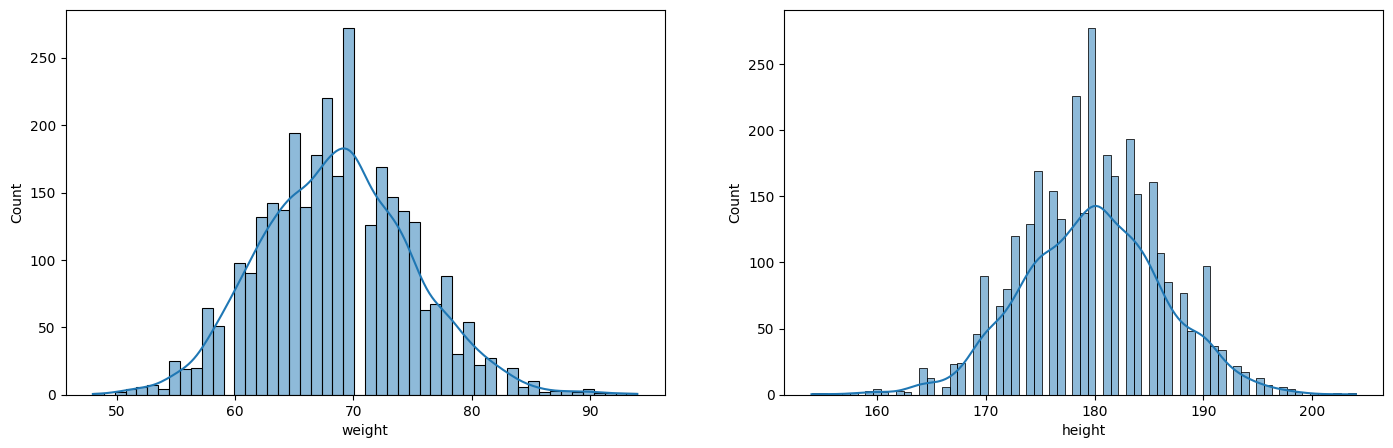

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(17, 5))

sns.histplot(cyclists, 
            x="weight", 
            bins=50, 
            kde=True,
            ax=axs[0])

sns.histplot(cyclists, 
            x="height", 
            bins=71, 
            kde=True,
            ax=axs[1])

Impute values of weight and height based on distribution

In [30]:
# Calculate the probability distribution of the weight and height columns
weights_distribution = cyclists['weight'].value_counts(normalize=True, dropna=True)
heights_distribution = cyclists['height'].value_counts(normalize=True, dropna=True)

In [31]:
# impute height and weight based on distribution

cyclists['height'] = cyclists['height'].apply(lambda x: np.random.choice(heights_distribution.index, p=heights_distribution.values) if pd.isnull(x) else x)
cyclists['weight'] = cyclists['weight'].apply(lambda x: np.random.choice(weights_distribution.index, p=weights_distribution.values) if pd.isnull(x) else x)

Plot histograms after imputation

<Axes: xlabel='height', ylabel='Count'>

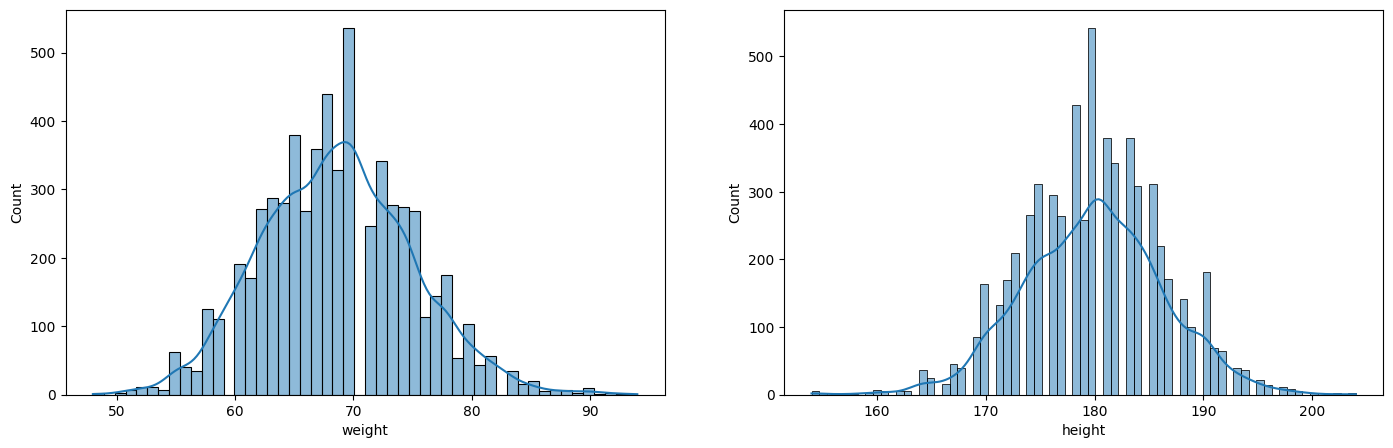

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(17, 5))

sns.histplot(cyclists, 
            x="weight", 
            bins=50, 
            kde=True,
            ax=axs[0])

sns.histplot(cyclists, 
            x="height", 
            bins=71, 
            kde=True,
            ax=axs[1])

In [33]:
# Let's see how many missing values there are

cyclists.isnull().sum()

_url            0
name            0
birth_year     13
weight          0
height          0
nationality     1
dtype: int64

# MERGE DATASETS

In [34]:
from utils import merge_dataset

merged_dataset = merge_dataset(dataset1 = cyclists,
                               dataset2 = races_imputed,
                               key_left = '_url',
                               key_right = 'cyclist')

In [35]:
merged_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 475399 entries, 0 to 475398
Data columns (total 18 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   _url_x             475399 non-null  object 
 1   name_x             475399 non-null  object 
 2   birth_year         475294 non-null  float64
 3   weight             475399 non-null  float64
 4   height             475399 non-null  float64
 5   nationality        475347 non-null  object 
 6   _url_y             475399 non-null  object 
 7   name_y             475399 non-null  object 
 8   points             474922 non-null  float64
 9   length             475399 non-null  float64
 10  profile            475399 non-null  float64
 11  startlist_quality  475399 non-null  int64  
 12  date               475399 non-null  object 
 13  position           475399 non-null  int64  
 14  cyclist            475399 non-null  object 
 15  cyclist_age        475294 non-null  float64
 16  is

In [36]:
merged_dataset.isnull().sum()

_url_x                 0
name_x                 0
birth_year           105
weight                 0
height                 0
nationality           52
_url_y                 0
name_y                 0
points               477
length                 0
profile                0
startlist_quality      0
date                   0
position               0
cyclist                0
cyclist_age          105
is_tarmac              0
delta                  0
dtype: int64

- Simply drop remaining null entries

In [37]:
clean_merged_dataset = merged_dataset.dropna()

In [38]:
clean_merged_dataset.isnull().sum()

_url_x               0
name_x               0
birth_year           0
weight               0
height               0
nationality          0
_url_y               0
name_y               0
points               0
length               0
profile              0
startlist_quality    0
date                 0
position             0
cyclist              0
cyclist_age          0
is_tarmac            0
delta                0
dtype: int64

- Conversion of numerical values to int since no entry should be float according to their meaning.

In [39]:
clean_merged_dataset = clean_merged_dataset.apply(lambda x: x.astype('int64') if x.dtype == 'float' else x)

In [40]:
clean_merged_dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 474817 entries, 0 to 475398
Data columns (total 18 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   _url_x             474817 non-null  object
 1   name_x             474817 non-null  object
 2   birth_year         474817 non-null  int64 
 3   weight             474817 non-null  int64 
 4   height             474817 non-null  int64 
 5   nationality        474817 non-null  object
 6   _url_y             474817 non-null  object
 7   name_y             474817 non-null  object
 8   points             474817 non-null  int64 
 9   length             474817 non-null  int64 
 10  profile            474817 non-null  int64 
 11  startlist_quality  474817 non-null  int64 
 12  date               474817 non-null  object
 13  position           474817 non-null  int64 
 14  cyclist            474817 non-null  object
 15  cyclist_age        474817 non-null  int64 
 16  is_tarmac          474817

- Change '_url_y' to 'race_id' for better understanding.

In [41]:
clean_merged_dataset.rename(columns={'_url_y': 'race_id'}, inplace=True)

In [42]:
clean_merged_dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 474817 entries, 0 to 475398
Data columns (total 18 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   _url_x             474817 non-null  object
 1   name_x             474817 non-null  object
 2   birth_year         474817 non-null  int64 
 3   weight             474817 non-null  int64 
 4   height             474817 non-null  int64 
 5   nationality        474817 non-null  object
 6   race_id            474817 non-null  object
 7   name_y             474817 non-null  object
 8   points             474817 non-null  int64 
 9   length             474817 non-null  int64 
 10  profile            474817 non-null  int64 
 11  startlist_quality  474817 non-null  int64 
 12  date               474817 non-null  object
 13  position           474817 non-null  int64 
 14  cyclist            474817 non-null  object
 15  cyclist_age        474817 non-null  int64 
 16  is_tarmac          474817

In [43]:
import pickle
import gzip

save = True

if save:
    with gzip.open('clean_merged_df.pkl', 'wb') as file:
        pickle.dump(clean_merged_dataset, file)